In [71]:
import itertools

import sympy as sy
import numpy as np

In [ ]:
import fitz
from PIL import Image
from IPython.display import display

In [58]:
doc = fitz.open('/home/tarsio/zotero-lib/AUTH/Blahut/Blahut_2010_Fast algorithms for signal processing.pdf')

In [80]:
def plot_pdf(page, crop=None):
    # (left, upper, right, lower)
    page.get_pixmap()
    mode = "RGBA" if pix.alpha else "RGB"
    image = Image.frombytes(mode, [pix.width, pix.height], pix.samples)
    if crop is None:
        display(image)
    else:
        display(image.crop(crop))

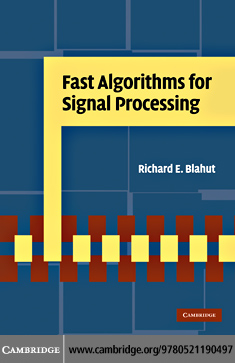

In [81]:
plot_pdf(doc[0])

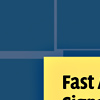

In [82]:
plot_pdf(doc[0], [0, 0, 100, 100])

Vamos usar como base o livro do Blahut

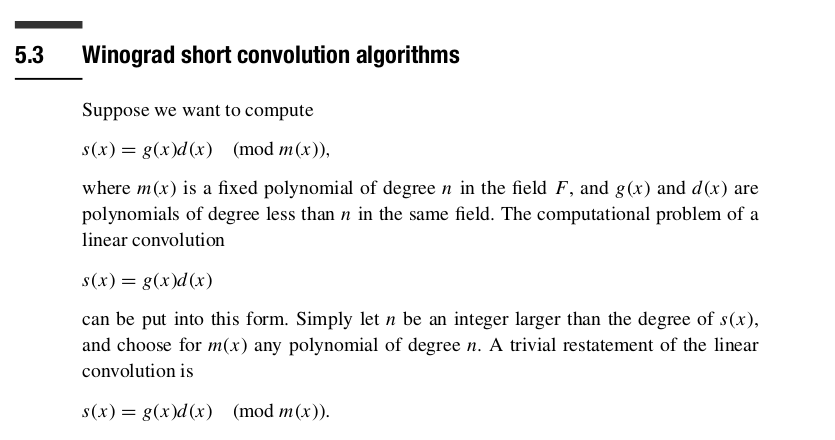

Tamanho dos vetores

In [2]:
d_num = 3
g_num = 2

Vetor de exemplo

In [3]:
d_values = list(range(1, d_num+1))
g_values = list(range(1, g_num+1))

Grau do polinômio

In [4]:
d_degree = d_num - 1
g_degree = g_num - 1

In [5]:
x = sy.symbols("x")
x

x

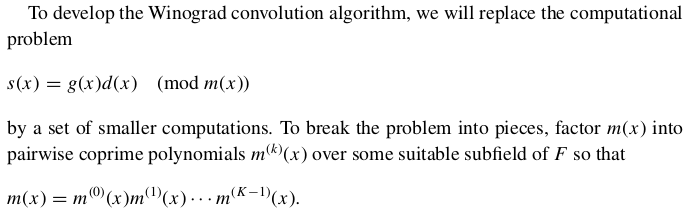

In [6]:
mk = sy.Matrix([x, x-1, x**2+1])
mk

Matrix([
[       x],
[   x - 1],
[x**2 + 1]])

In [7]:
di = sy.Matrix(sy.symbols(" ".join(f"d{i}"for i in range(d_num))))
di

Matrix([
[d0],
[d1],
[d2]])

In [8]:
di2 = sy.Matrix(sy.symbols(" ".join(f"d{i}^2"for i in range(g_num))))
di2

Matrix([
[d0^2],
[d1^2]])

In [9]:
gi = sy.Matrix(sy.symbols(" ".join(f"g{i}"for i in range(g_num))))
gi

Matrix([
[g0],
[g1]])

In [10]:
gi2 = sy.Matrix(sy.symbols(" ".join(f"g{i}^(2)"for i in range(g_num))))
gi2

Matrix([
[g0^(2)],
[g1^(2)]])

In [11]:
dx = sum([i*x**e for e, i in enumerate(di)])
dx

d0 + d1*x + d2*x**2

In [12]:
gx = sum([i*x**e for e, i in enumerate(gi)])
gx

g0 + g1*x

In [13]:
sx = gx*dx
sx

(g0 + g1*x)*(d0 + d1*x + d2*x**2)

In [55]:
gk = sy.Matrix([sy.div(gx, q, domain ='QQ')[1] for q in mk])
gk

Matrix([
[       g0],
[  g0 + g1],
[g0 + g1*x]])

In [56]:
dk = sy.Matrix([sy.div(dx, q, domain ='QQ')[1] for q in mk])
dk

Matrix([
[            d0],
[  d0 + d1 + d2],
[d0 + d1*x - d2]])

In [16]:
mmk = sy.Matrix([sy.expand(np.prod(d)) for d in itertools.combinations(reversed(mk), len(mk)-1)])
# mmk = mmk_ + [sy.expand(np.prod(mk))]
mmk

Matrix([
[x**3 - x**2 + x - 1],
[           x**3 + x],
[           x**2 - x]])

Pegando quociente e resto, agora tem q colocar no formato nm+NM=1

In [17]:
mx_div = [sy.div(dv, ds, domain ='QQ') for dv, ds in zip(mmk, mk)]
mx_div

[(x**2 - x + 1, -1), (x**2 + x + 2, 2), (1, -x - 1)]

In [18]:
sy.Matrix([x[0] for x in mx_div])

Matrix([
[x**2 - x + 1],
[x**2 + x + 2],
[           1]])

In [19]:
sy.Matrix([x[1] for x in mx_div])

Matrix([
[    -1],
[     2],
[-x - 1]])

In [20]:
nnk = sy.Matrix([1/z[1] for z in mx_div])
nnk

Matrix([
[        -1],
[       1/2],
[1/(-x - 1)]])

# S2 livro

In [21]:
a2_mtx = sy.Matrix([[1, 1], [1, 0], [0, 1]])
a2_mtx

Matrix([
[1, 1],
[1, 0],
[0, 1]])

In [22]:
b2_mtx = sy.Matrix([[1, 0], [-1, 1], [1, 1]])
b2_mtx

Matrix([
[ 1, 0],
[-1, 1],
[ 1, 1]])

In [23]:
c2_mtx = sy.Matrix([
    [1, 0, -1],
    [1, 1, 0],
])
c2_mtx


Matrix([
[1, 0, -1],
[1, 1,  0]])

# S2 Társio

In [24]:
mx_div2 = sy.div(mk[-1], mx_div[-1][1], domain ='QQ')
mx_div2

(1 - x, 2)

In [25]:
nnk2 = mx_div2[0]/mx_div2[1]
nnk2 = nnk2*(-1) if nnk2.coeff(x).is_negative else nnk2
nnk2


x/2 - 1/2

n (pequeno) não é usado pra nada mas acho que é assim q se define ele

In [26]:
nk2 = (mx_div[-1][0] + mx_div2[0])/mx_div2[1]
nk2

1 - x/2

In [27]:
c20_lst = sy.expand(mmk[-1]*mx_div2[0])
c20_lst

-x**3 + 2*x**2 - x

In [28]:
c21_lst = sy.div(np.prod(mk), sy.expand(c20_lst*x), domain ='QQ')[1]
c21_lst


x**3 - x

# Juntando s2 do livro com s0 e s1

In [29]:
a0_lst = [[d.coeff(c, 1) for c in di] for d in dk[:-1]]
a0_lst

[[1, 0, 0], [1, 1, 1]]

In [30]:
a20_lst = [dk[-1].subs({x:0}).coeff(c, 1) for c in di]
a20_lst

[1, 0, -1]

In [31]:
a21_lst = [sy.div(dk[-1], c, domain ='QQ')[0].subs({x:1}) for c in di]
a21_lst

[0, 1, 0]

In [32]:
a0_mtx = sy.Matrix(np.vstack([a0_lst, a20_lst, a21_lst]))
a0_mtx

Matrix([
[1, 0,  0],
[1, 1,  1],
[1, 0, -1],
[0, 1,  0]])

In [33]:
a2_mtx = sy.Matrix(sy.diag(sy.eye(2), a2_mtx))
a2_mtx

Matrix([
[1, 0, 0, 0],
[0, 1, 0, 0],
[0, 0, 1, 1],
[0, 0, 1, 0],
[0, 0, 0, 1]])

In [34]:
a_mtx = a2_mtx * a0_mtx
a_mtx

Matrix([
[1, 0,  0],
[1, 1,  1],
[1, 1, -1],
[1, 0, -1],
[0, 1,  0]])

In [35]:
b0_lst = [[g.coeff(c, 1) for c in gi] for g in gk[:-1]]
b0_lst

[[1, 0], [1, 1]]

In [36]:
b20_lst = [gk[-1].subs({x:0}).coeff(c, 1) for c in gi]
b20_lst

[1, 0]

In [37]:
b21_lst = [sy.div(gk[-1], c, domain ='QQ')[0].subs({x:1}) for c in gi]
b21_lst

[0, 1]

In [38]:
b0_mtx = sy.Matrix(np.vstack([b0_lst, b20_lst, b21_lst]))
b0_mtx


Matrix([
[1, 0],
[1, 1],
[1, 0],
[0, 1]])

In [39]:
b2_mtx = sy.Matrix(sy.diag(sy.eye(2), b2_mtx))
b2_mtx

Matrix([
[1, 0,  0, 0],
[0, 1,  0, 0],
[0, 0,  1, 0],
[0, 0, -1, 1],
[0, 0,  1, 1]])

In [40]:
b_mtx = b2_mtx * b0_mtx
b_mtx


Matrix([
[ 1, 0],
[ 1, 1],
[ 1, 0],
[-1, 1],
[ 1, 1]])

Multiplicar o resto pea_lst matriz G depois
O sinal negativo vai pra matriz G e não pra C


In [41]:
g_mtx = sy.diag(*(nnk[:-1] + [nnk2.subs({x:0})]*(d_num+g_num - len(nnk[:-1]))))
g_mtx

Matrix([
[-1,   0,    0,    0,    0],
[ 0, 1/2,    0,    0,    0],
[ 0,   0, -1/2,    0,    0],
[ 0,   0,    0, -1/2,    0],
[ 0,   0,    0,    0, -1/2]])

In [42]:
bg_mtx = sy.diag(*(g_mtx*b_mtx*sy.Matrix(gi)).tolist())
bg_mtx

Matrix([
[-g0,           0,     0,           0,            0],
[  0, g0/2 + g1/2,     0,           0,            0],
[  0,           0, -g0/2,           0,            0],
[  0,           0,     0, g0/2 - g1/2,            0],
[  0,           0,     0,           0, -g0/2 - g1/2]])

In [43]:
nk = [q[0]*r*(-1) for q, r in zip(mx_div[:-1], nnk[:-1])] + [nnk2]
nk

[x**2 - x + 1, -x**2/2 - x/2 - 1, x/2 - 1/2]

colocar em forma matricial


In [44]:
c_lst = [[d.coeff(x, c) for d in mmk[:-1] + [c20_lst] + [c21_lst]] for c in range(len(np.prod(mk).as_poly().all_coeffs())-1)]
c_lst

[[-1, 0, 0, 0], [1, 1, -1, -1], [-1, 0, 2, 0], [1, 1, -1, 1]]

In [45]:
c0_mtx = sy.Matrix(c_lst)
c0_mtx

Matrix([
[-1, 0,  0,  0],
[ 1, 1, -1, -1],
[-1, 0,  2,  0],
[ 1, 1, -1,  1]])

In [46]:
c2_mtx = sy.Matrix(sy.diag(sy.eye(2), c2_mtx))
c2_mtx

Matrix([
[1, 0, 0, 0,  0],
[0, 1, 0, 0,  0],
[0, 0, 1, 0, -1],
[0, 0, 1, 1,  0]])

In [47]:
c_mtx = c0_mtx * c2_mtx
c_mtx

Matrix([
[-1, 0,  0,  0,  0],
[ 1, 1, -2, -1,  1],
[-1, 0,  2,  0, -2],
[ 1, 1,  0,  1,  1]])

In [48]:
s = sy.MatMul(c_mtx, bg_mtx, a_mtx, sy.Matrix(di))
s

Matrix([
[-1, 0,  0,  0,  0],
[ 1, 1, -2, -1,  1],
[-1, 0,  2,  0, -2],
[ 1, 1,  0,  1,  1]])*Matrix([
[-g0,           0,     0,           0,            0],
[  0, g0/2 + g1/2,     0,           0,            0],
[  0,           0, -g0/2,           0,            0],
[  0,           0,     0, g0/2 - g1/2,            0],
[  0,           0,     0,           0, -g0/2 - g1/2]])*Matrix([
[1, 0,  0],
[1, 1,  1],
[1, 1, -1],
[1, 0, -1],
[0, 1,  0]])*Matrix([
[d0],
[d1],
[d2]])

In [49]:
subs = {k[0]: v for k, v in zip(di.tolist()+gi.tolist(), d_values + g_values)}
subs

{d0: 1, d1: 2, d2: 3, g0: 1, g1: 2}

In [50]:
si = s.subs(subs)
si

Matrix([
[-1, 0,  0,  0,  0],
[ 1, 1, -2, -1,  1],
[-1, 0,  2,  0, -2],
[ 1, 1,  0,  1,  1]])*Matrix([
[-1,   0,    0,    0,    0],
[ 0, 3/2,    0,    0,    0],
[ 0,   0, -1/2,    0,    0],
[ 0,   0,    0, -1/2,    0],
[ 0,   0,    0,    0, -3/2]])*Matrix([
[1, 0,  0],
[1, 1,  1],
[1, 1, -1],
[1, 0, -1],
[0, 1,  0]])*Matrix([
[1],
[2],
[3]])

In [51]:
sy.expand(sx)

d0*g0 + d0*g1*x + d1*g0*x + d1*g1*x**2 + d2*g0*x**2 + d2*g1*x**3

In [52]:
se = sy.MatMul(c_mtx, bg_mtx, a_mtx, sy.Matrix(di), evaluate=True)
se

Matrix([
[        d0*g0],
[d0*g1 + d1*g0],
[d1*g1 + d2*g0],
[        d2*g1]])

In [53]:
out = np.convolve(d_values, g_values)
print(out)

[1 4 7 6]


In [54]:
se.subs(subs)

Matrix([
[1],
[4],
[7],
[6]])